<a href="https://colab.research.google.com/github/mptorpo/integracion_prospectiva_y_datos/blob/main/Proyecto_Final_SaraC_MarianaC_MiguelR_MiguelP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto Final: Integración de Biomarcadores Clínicos y Factores de Estilo de Vida para Predicción de Riesgo Cardiovascular**

- Sara Castaño, Epik ID 1000290143
- Mariana Castrillón, Epik ID 1000291852
- Miguel Robledo, Epik ID 1000295939
- Miguel Pimiento, Epik ID 1000293648

**Descripción del Caso:** Una entidad del sector salud busca construir un índice integrado de riesgo cardiovascular a partir de dos fuentes clínicas independientes: el Framingham Heart Study (4.240 registros, EE. UU.) y el Cardiovascular Disease Dataset (70.000 registros, Europa del Este). El objetivo es determinar, mediante un proceso de integración multidimensional, perfiles de riesgo compartidos entre ambas poblaciones que permitan orientar estrategias de intervención preventiva temprana y priorizar la asignación de recursos clínicos hacia los grupos de mayor vulnerabilidad cardiovascular.

**Metodología:** Para la integración multidimensional se emplean dos modelos complementarios vistos en clase:

1. **Mapas de Integración Borrosos (Fuzzy Integration Maps):** modelo desarrollado en el Parcial II. Permite clasificar a cada paciente en zonas de riesgo cardiovascular difuso (Bajo, Moderado, Alto) a partir de funciones de pertenencia triangulares definidas sobre cada variable numérica compartida. La lógica borrosa captura los estados intermedios de riesgo, clínicamente relevantes: un paciente con presión arterial de 138 mmHg no es claramente hipertenso ni claramente sano, y el modelo refleja esa incertidumbre.
2. **Integración Multidimensional K-Medoids:** modelo desarrollado en el Reto 4. Permite agrupar a todos los pacientes (de ambas cohortes) en *segmentos* o *perfiles* que se construyen iterativamente sobre el conjunto de variables numéricas comunes y validan los hallazgos del modelo borroso.

**Descripción de las Variables**

**Framingham Heart Study (XDB) — 4.240 registros, 16 variables**
- `male`: género del paciente (1 = masculino, 0 = femenino).
- `age`: edad en años cumplidos.
- `education`: nivel educativo (1 a 4).
- `currentSmoker`: fumador activo (1 = sí, 0 = no).
- `cigsPerDay`: cigarrillos consumidos por día.
- `BPMeds`: paciente bajo medicación antihipertensiva (1/0).
- `prevalentStroke`: antecedente de ictus (1/0).
- `prevalentHyp`: hipertensión previa diagnosticada (1/0).
- `diabetes`: diabetes diagnosticada (1/0).
- `totChol`: colesterol total (mg/dL).
- `sysBP`: presión arterial sistólica (mmHg).
- `diaBP`: presión arterial diastólica (mmHg).
- `BMI`: índice de masa corporal (kg/m²).
- `heartRate`: frecuencia cardiaca (latidos/min).
- `glucose`: glucosa en sangre (mg/dL).
- `TenYearCHD`: variable objetivo — riesgo de enfermedad coronaria a 10 años (1/0).

**Cardiovascular Disease Dataset (YDB) — 70.000 registros, 13 variables**
- `id`: identificador único.
- `age`: edad en días.
- `gender`: género (1 = femenino, 2 = masculino).
- `height`: estatura (cm).
- `weight`: peso (kg).
- `ap_hi`: presión arterial sistólica (mmHg).
- `ap_lo`: presión arterial diastólica (mmHg).
- `cholesterol`: nivel de colesterol categorizado (1 = normal, 2 = sobre lo normal, 3 = muy por encima).
- `gluc`: nivel de glucosa categorizado (1, 2, 3).
- `smoke`, `alco`, `active`: hábitos de vida (1/0).
- `cardio`: variable objetivo — presencia de enfermedad cardiovascular (1/0).

**Variables Potenciales de Integración:** Las dos bases comparten cuatro variables numéricas con interpretación clínica equivalente. Estas cuatro variables son la base de los dos procesos de integración.

- **Edad:** años
- **Presión Arterial Sistólica:** "sysBP" en Framingham = "ap_hi" en Cardio
- **Presión Arterial Diastólica:** "diaBP" en Framingham = "ap_lo" en Cardio
- **Índice de Masa Corporal:** "BMI" en Framingham, calculado a partir de "height" y "weight" en Cardio


# **Código**

**0. Se procede con la carga de las librerías de trabajo**

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

**1. Se procede con la carga de las bases de datos**

Se descargan ambas bases de datos directamente desde Kaggle por medio de la librería `kagglehub`. La primera es la base del Framingham Heart Study (EE. UU.) y la segunda es el Cardiovascular Disease Dataset (Europa del Este).

In [3]:
# Se instala la librería de descarga directa desde Kaggle
!pip install -q kagglehub
import kagglehub

# Se descarga la versión más reciente de cada base de datos
path1 = kagglehub.dataset_download("aasheesh200/framingham-heart-study-dataset")
path2 = kagglehub.dataset_download("sulianova/cardiovascular-disease-dataset")

print("Ruta Framingham:", path1)
print("Ruta Cardio:    ", path2)

100%|██████████| 58.0k/58.0k [00:00<00:00, 1.14MB/s]

Extracting files...


Using Colab cache for faster access to the 'cardiovascular-disease-dataset' dataset.
Ruta Framingham: /root/.cache/kagglehub/datasets/aasheesh200/framingham-heart-study-dataset/versions/1
Ruta Cardio:     /kaggle/input/cardiovascular-disease-dataset


In [4]:
# Se carga la base interna (Framingham) y la base externa (Cardio)
XDB = pd.read_csv(f'{path1}/framingham.csv')           # Datos internos
YDB = pd.read_csv(f'{path2}/cardio_train.csv', sep=';') # Datos externos

print("Framingham — Shape:", XDB.shape)
XDB.head()

Framingham — Shape: (4240, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [5]:
print("Cardiovascular Disease — Shape:", YDB.shape)
YDB.head()

Cardiovascular Disease — Shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


**2. Se procede con la limpieza de los datos y la armonización de las variables comunes**

Se eliminan los valores nulos, se ajustan unidades (edad en años, BMI calculado), se descartan los registros con presiones arteriales fisiológicamente imposibles y se construye la base unificada XU con las cuatro variables comunes.

In [6]:
# Tratamiento de valores nulos en la base interna (Framingham)
print("Nulos antes (Framingham):")
print(XDB.isnull().sum().to_string())

XDB.dropna(inplace=True)

print("\nFramingham luego de limpieza — Shape:", XDB.shape)

Nulos antes (Framingham):
male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0

Framingham luego de limpieza — Shape: (3658, 16)


In [7]:
# Tratamiento de valores nulos en la base externa (Cardio)
print("Nulos antes (Cardio):")
print(YDB.isnull().sum().to_string())

YDB.dropna(inplace=True)
YDB.drop('id', axis=1, inplace=True) # Identificador no aporta al análisis

print("\nCardio luego de limpieza — Shape:", YDB.shape)

Nulos antes (Cardio):
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0

Cardio luego de limpieza — Shape: (70000, 12)


In [8]:
# Armonización de variables
# Edad de Cardio: de días a años
YDB['age'] = (YDB['age'] / 365.25).round().astype(int)

# Género: en Cardio (1=femenino, 2=masculino) → se transforma a 'male' como en Framingham
YDB['male'] = (YDB['gender'] == 2).astype(int)
YDB.drop('gender', axis=1, inplace=True)

# BMI en Cardio: kg/m² a partir de peso y estatura
YDB['BMI'] = YDB['weight'] / (YDB['height'] / 100) ** 2

YDB.head()

,age,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,male,BMI
0,50,168,62.0,110,80,1,1,0,0,1,0,1,21.967120
1,55,156,85.0,140,90,3,1,0,0,1,1,0,34.927679
2,52,165,64.0,130,70,3,1,0,0,0,1,0,23.507805
3,48,169,82.0,150,100,1,1,0,0,1,1,1,28.710479
4,48,156,56.0,100,60,1,1,0,0,0,0,0,23.011177


In [9]:
# Filtro de outliers fisiológicamente imposibles en Cardio
# (ap_hi y ap_lo están reportados con errores de digitación en la base original)
antes = len(YDB)
YDB = YDB[(YDB['ap_hi'] > 60) & (YDB['ap_hi'] < 250)]
YDB = YDB[(YDB['ap_lo'] > 40) & (YDB['ap_lo'] < 200)]
YDB = YDB[YDB['ap_hi'] > YDB['ap_lo']]
YDB = YDB[(YDB['BMI'] > 12) & (YDB['BMI'] < 60)]
print(f"Registros descartados por outliers fisiológicos: {antes - len(YDB)}")
print(f"Cardio final — Shape: {YDB.shape}")

Registros descartados por outliers fisiológicos: 1413
Cardio final — Shape: (68587, 13)


In [10]:
# Construcción de la base unificada XU con las cuatro variables comunes
# Se renombran las variables de Cardio para que coincidan con Framingham
X1 = XDB[['age', 'sysBP', 'diaBP', 'BMI']].rename(columns={'sysBP': 'PA_sist', 'diaBP': 'PA_diast'})
X1['cardio'] = XDB['TenYearCHD'].values
X1['fuente'] = 'Framingham'

X2 = YDB[['age', 'ap_hi', 'ap_lo', 'BMI']].rename(columns={'ap_hi': 'PA_sist', 'ap_lo': 'PA_diast'})
X2['cardio'] = YDB['cardio'].values
X2['fuente'] = 'Cardio'

XU = pd.concat([X1, X2], ignore_index=True)
XU = XU.sample(frac=1, random_state=42).reset_index(drop=True) # Se ofuscan los datos

print("Base unificada XU — Shape:", XU.shape)
print("Distribución por fuente:")
print(XU['fuente'].value_counts())
XU.head()

Base unificada XU — Shape: (72245, 6)
Distribución por fuente:
fuente
Cardio        68587
Framingham     3658
Name: count, dtype: int64


,age,PA_sist,PA_diast,BMI,cardio,fuente
0,49,130.0,90.0,30.468750,1,Cardio
1,62,120.0,80.0,23.051755,1,Cardio
2,56,120.0,80.0,29.296875,0,Cardio
3,52,110.0,60.0,24.382373,0,Cardio
4,54,130.0,80.0,24.973985,0,Cardio


**3. Se procede con la caracterización estadística de las variables comunes**

Se define la función caracterizacion (utilizada en parciales y retos anteriores) que entrega para cada variable la media, varianza, desviación, asimetría, curtosis y un histograma con densidad.

In [11]:
# Función de caracterización estadística
def caracterizacion(LDA, nombre=""):

  # Se procede con la creación de la distribución
  plt.figure(figsize=(10, 4))
  sns.histplot(LDA, bins=20, kde=True)
  plt.xlabel(nombre)
  plt.title(f"Distribución de {nombre}")
  plt.grid()
  plt.show()

  # Métricas de tendencia central y dispersión
  u = np.mean(LDA)
  var = np.var(LDA)
  sigma = np.std(LDA)
  Cas = skew(LDA)
  Kur = kurtosis(LDA)

  print(f"Media:      {u:.4f}")
  print(f"Varianza:   {var:.4f}")
  print(f"Desviación: {sigma:.4f}")
  print(f"Asimetría:  {Cas:.4f}")
  print(f"Curtosis:   {Kur:.4f}")

  return u, sigma, Cas, Kur

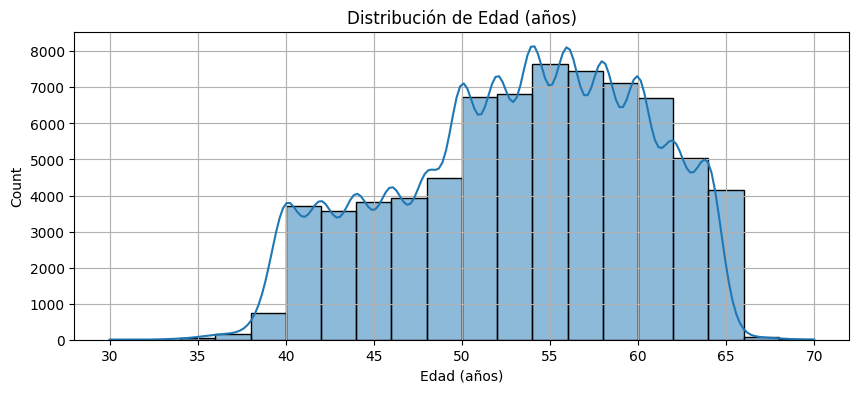

Media:      53.1024
Varianza:   47.7925
Desviación: 6.9132
Asimetría:  -0.3008
Curtosis:   -0.8137


In [12]:
# Caracterización de Edad (años)
u_edad, sigma_edad, _, _ = caracterizacion(XU['age'], "Edad (años)")

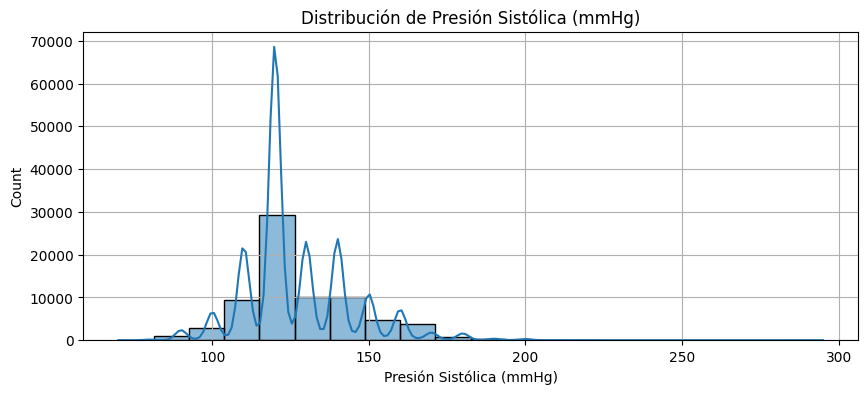

Media:      126.9616
Varianza:   290.4748
Desviación: 17.0433
Asimetría:  0.9991
Curtosis:   2.1374


In [13]:
# Caracterización de Presión Arterial Sistólica (mmHg)
u_sist, sigma_sist, _, _ = caracterizacion(XU['PA_sist'], "Presión Sistólica (mmHg)")

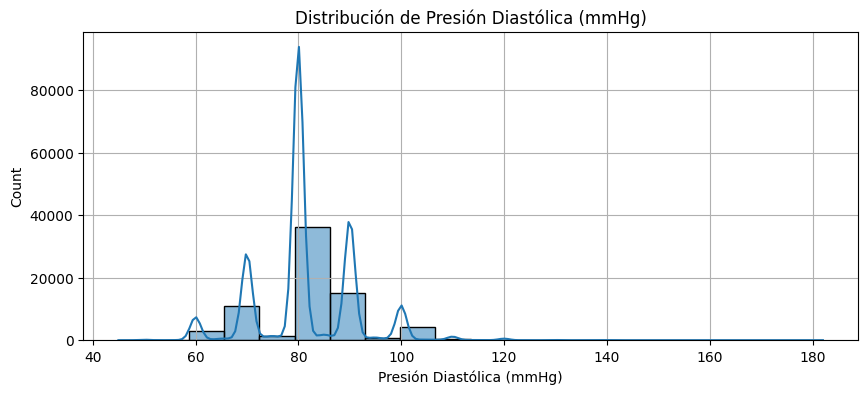

Media:      81.3967
Varianza:   91.8636
Desviación: 9.5846
Asimetría:  0.4402
Curtosis:   2.1127


In [14]:
# Caracterización de Presión Arterial Diastólica (mmHg)
u_diast, sigma_diast, _, _ = caracterizacion(XU['PA_diast'], "Presión Diastólica (mmHg)")

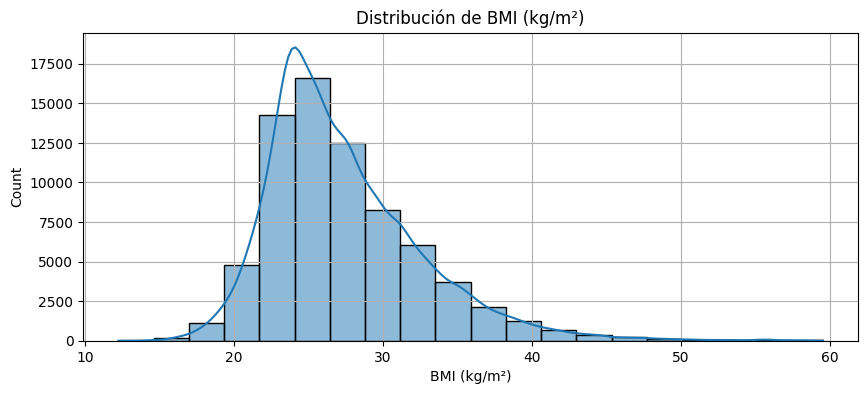

Media:      27.3638
Varianza:   26.7334
Desviación: 5.1704
Asimetría:  1.1976
Curtosis:   2.4785


In [15]:
# Caracterización del Índice de Masa Corporal (kg/m²)
u_bmi, sigma_bmi, _, _ = caracterizacion(XU['BMI'], "BMI (kg/m²)")

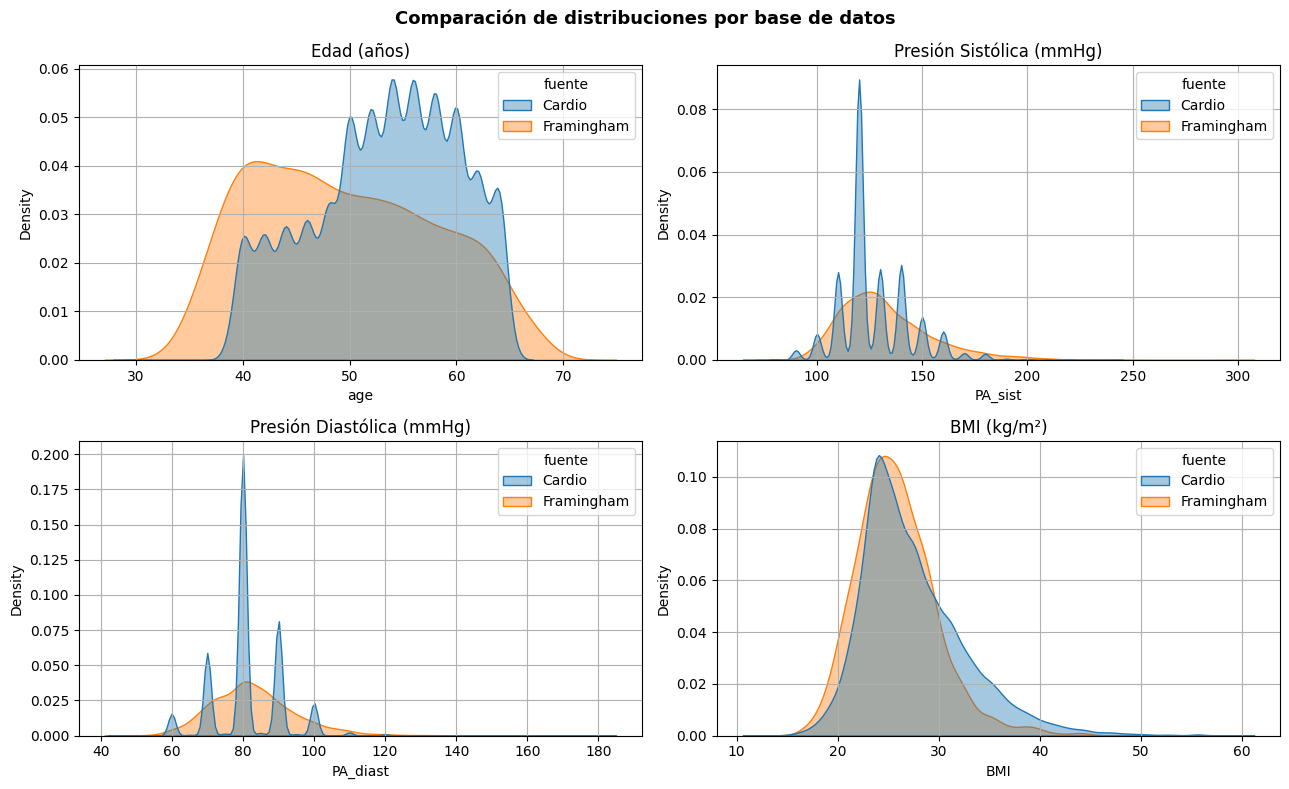

In [16]:
# Comparación de las distribuciones por fuente (Framingham vs Cardio)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, var, titulo in zip(axes.flatten(),
                           ['age', 'PA_sist', 'PA_diast', 'BMI'],
                           ['Edad (años)', 'Presión Sistólica (mmHg)', 'Presión Diastólica (mmHg)', 'BMI (kg/m²)']):
    sns.kdeplot(data=XU, x=var, hue='fuente', fill=True, common_norm=False, alpha=0.4, ax=ax)
    ax.set_title(titulo)
    ax.grid()

plt.suptitle('Comparación de distribuciones por base de datos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**4. Modelo I — Mapas de Integración Borrosos (Fuzzy Integration Maps)**

Se construye el modelo de mapas de integración borrosos para clasificar a cada paciente en una de tres zonas de riesgo cardiovascular: Bajo, Moderado o Alto. El modelo opera en tres pasos:

1. **Fuzzificación:** para cada variable numérica común (edad, presión sistólica, presión diastólica y BMI) se definen tres funciones de pertenencia triangulares (bajo, moderado y alto) basadas en umbrales clínicos reconocidos (JNC8 para presión, OMS para BMI).
2. **Agregación:** para cada paciente se calcula el grado de pertenencia a cada nivel de riesgo como el promedio de las pertenencias parciales sobre las cuatro variables.
3. **Defuzzificación:** se asigna al paciente la zona de riesgo cuyo grado de pertenencia agregado sea máximo.

El uso de funciones de pertenencia triangulares (y no de cortes binarios) permite reflejar la naturaleza gradual del riesgo cardiovascular.

In [17]:
# Definición de las funciones de pertenencia triangulares

def mu_left(x, b, c):
    # Pertenencia decreciente: 1 si x<=b, 0 si x>=c, lineal entre b y c
    x = np.asarray(x, dtype=float)
    return np.where(x <= b, 1.0, np.where(x >= c, 0.0, (c - x) / (c - b)))

def mu_triang(x, a, b, c):
    # Pertenencia triangular: sube de a->b y baja de b->c
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    sube = (x >= a) & (x <= b)
    baja = (x > b) & (x <= c)
    out[sube] = (x[sube] - a) / (b - a)
    out[baja] = (c - x[baja]) / (c - b)
    return out

def mu_right(x, a, b):
    # Pertenencia creciente: 0 si x<=a, 1 si x>=b, lineal entre a y b
    x = np.asarray(x, dtype=float)
    return np.where(x <= a, 0.0, np.where(x >= b, 1.0, (x - a) / (b - a)))

In [18]:
# Definición de los umbrales clínicos por variable
#   Edad:         Bajo ≤45,  Moderado 45-60,  Alto ≥60
#   PA Sistólica: Bajo ≤120, Moderado 120-140, Alto ≥140  (JNC8)
#   PA Diastólica: Bajo ≤80,  Moderado 80-90,   Alto ≥90  (JNC8)
#   BMI:          Bajo ≤25,  Moderado 25-30,  Alto ≥30  (OMS)

mu = {}

# Edad
mu['age']      = {'bajo':  mu_left(XU['age'], 45, 55),
                  'mod':   mu_triang(XU['age'], 45, 55, 65),
                  'alto':  mu_right(XU['age'], 55, 65)}

# Presión Sistólica
mu['PA_sist']  = {'bajo':  mu_left(XU['PA_sist'], 120, 130),
                  'mod':   mu_triang(XU['PA_sist'], 120, 135, 150),
                  'alto':  mu_right(XU['PA_sist'], 135, 150)}

# Presión Diastólica
mu['PA_diast'] = {'bajo':  mu_left(XU['PA_diast'], 80, 85),
                  'mod':   mu_triang(XU['PA_diast'], 80, 90, 100),
                  'alto':  mu_right(XU['PA_diast'], 90, 100)}

# BMI
mu['BMI']      = {'bajo':  mu_left(XU['BMI'], 25, 27),
                  'mod':   mu_triang(XU['BMI'], 25, 28, 32),
                  'alto':  mu_right(XU['BMI'], 28, 32)}

print("Funciones de pertenencia evaluadas para todos los pacientes.")

Funciones de pertenencia evaluadas para todos los pacientes.


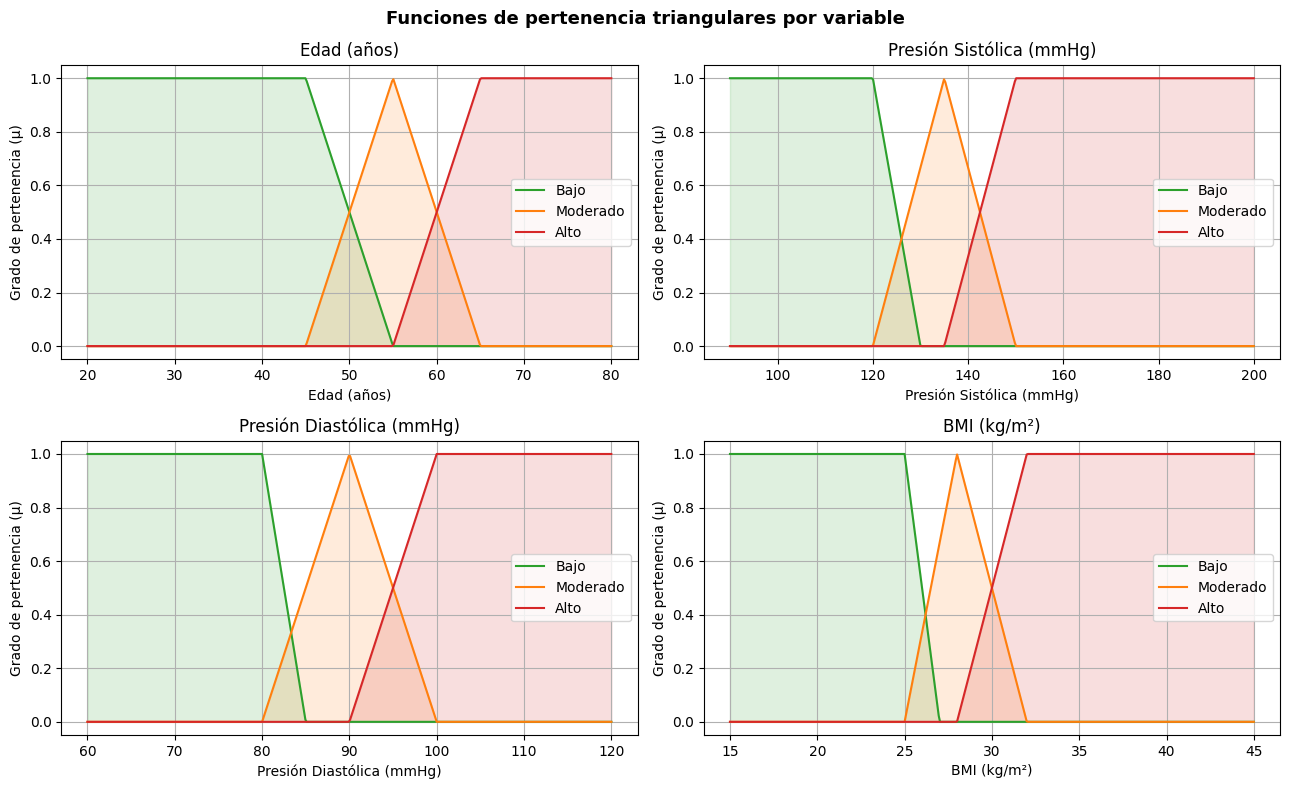

In [19]:
# Visualización de las funciones de pertenencia por variable
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
rangos = {'age': (20, 80), 'PA_sist': (90, 200), 'PA_diast': (60, 120), 'BMI': (15, 45)}
titulos = {'age': 'Edad (años)', 'PA_sist': 'Presión Sistólica (mmHg)',
           'PA_diast': 'Presión Diastólica (mmHg)', 'BMI': 'BMI (kg/m²)'}

for ax, var in zip(axes.flatten(), ['age', 'PA_sist', 'PA_diast', 'BMI']):
    xs = np.linspace(rangos[var][0], rangos[var][1], 400)
    if var == 'age':
        b = mu_left(xs, 45, 55); m = mu_triang(xs, 45, 55, 65); a = mu_right(xs, 55, 65)
    elif var == 'PA_sist':
        b = mu_left(xs, 120, 130); m = mu_triang(xs, 120, 135, 150); a = mu_right(xs, 135, 150)
    elif var == 'PA_diast':
        b = mu_left(xs, 80, 85); m = mu_triang(xs, 80, 90, 100); a = mu_right(xs, 90, 100)
    else:
        b = mu_left(xs, 25, 27); m = mu_triang(xs, 25, 28, 32); a = mu_right(xs, 28, 32)
    ax.plot(xs, b, color='#2ca02c', label='Bajo')
    ax.plot(xs, m, color='#ff7f0e', label='Moderado')
    ax.plot(xs, a, color='#d62728', label='Alto')
    ax.fill_between(xs, 0, b, color='#2ca02c', alpha=0.15)
    ax.fill_between(xs, 0, m, color='#ff7f0e', alpha=0.15)
    ax.fill_between(xs, 0, a, color='#d62728', alpha=0.15)
    ax.set_title(titulos[var])
    ax.set_xlabel(titulos[var]); ax.set_ylabel('Grado de pertenencia (μ)')
    ax.legend(); ax.grid()

plt.suptitle('Funciones de pertenencia triangulares por variable', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# Agregación: promedio de la pertenencia parcial por nivel de riesgo
mu_bajo = (mu['age']['bajo']     + mu['PA_sist']['bajo']  + mu['PA_diast']['bajo']  + mu['BMI']['bajo'])  / 4
mu_mod  = (mu['age']['mod']      + mu['PA_sist']['mod']   + mu['PA_diast']['mod']   + mu['BMI']['mod'])   / 4
mu_alto = (mu['age']['alto']     + mu['PA_sist']['alto']  + mu['PA_diast']['alto']  + mu['BMI']['alto'])  / 4

# Defuzzificación: cada paciente queda asignado al nivel con mayor pertenencia
riesgo_idx = np.argmax(np.column_stack([mu_bajo, mu_mod, mu_alto]), axis=1)
mapa_etq = {0: 'Bajo', 1: 'Moderado', 2: 'Alto'}
XU['mu_Bajo']      = np.round(mu_bajo, 4)
XU['mu_Moderado']  = np.round(mu_mod, 4)
XU['mu_Alto']      = np.round(mu_alto, 4)
XU['Zona_Riesgo']  = [mapa_etq[i] for i in riesgo_idx]

print("Distribución de pacientes por zona de riesgo borroso:")
print(XU['Zona_Riesgo'].value_counts())
XU[['age', 'PA_sist', 'PA_diast', 'BMI', 'mu_Bajo', 'mu_Moderado', 'mu_Alto', 'Zona_Riesgo']].head(10)

Distribución de pacientes por zona de riesgo borroso:
Zona_Riesgo
Bajo        47713
Moderado    15759
Alto         8773
Name: count, dtype: int64


,age,PA_sist,PA_diast,BMI,mu_Bajo,mu_Moderado,mu_Alto,Zona_Riesgo
0,49,130.0,90.0,30.468750,0.1500,0.6124,0.1543,Moderado
1,62,120.0,80.0,23.051755,0.7500,0.0750,0.1750,Bajo
2,56,120.0,80.0,29.296875,0.5000,0.3939,0.1061,Bajo
3,52,110.0,60.0,24.382373,0.8250,0.1750,0.0000,Bajo
4,54,130.0,80.0,24.973985,0.5250,0.3917,0.0000,Bajo
5,61,130.0,90.0,26.575891,0.0530,0.6480,0.1500,Moderado
6,58,120.0,80.0,24.677021,0.7500,0.1750,0.0750,Bajo
7,50,130.0,90.0,34.894399,0.1250,0.5417,0.2500,Moderado
8,50,130.0,80.0,25.432686,0.5709,0.3277,0.0000,Bajo
9,46,120.0,80.0,24.034610,0.9750,0.0250,0.0000,Bajo


In [21]:
# Mapa de Integración Borrosa: incidencia de evento cardiovascular por zona
tabla = XU.groupby('Zona_Riesgo').agg(
    N_Pacientes=('cardio', 'size'),
    Tasa_Evento=('cardio', 'mean'),
    Edad_Media=('age', 'mean'),
    PA_sist_Media=('PA_sist', 'mean'),
    PA_diast_Media=('PA_diast', 'mean'),
    BMI_Media=('BMI', 'mean')
).round(3)
tabla = tabla.reindex(['Bajo', 'Moderado', 'Alto'])
print("Mapa de Integración Borrosa — Perfiles por zona de riesgo")
display(tabla)

Mapa de Integración Borrosa — Perfiles por zona de riesgo


,N_Pacientes,Tasa_Evento,Edad_Media,PA_sist_Media,PA_diast_Media,BMI_Media
Zona_Riesgo,,,,,,
Bajo,47713,0.346,51.778,118.486,76.926,26.022
Moderado,15759,0.699,54.897,137.307,87.668,28.807
Alto,8773,0.793,57.079,154.476,94.448,32.068


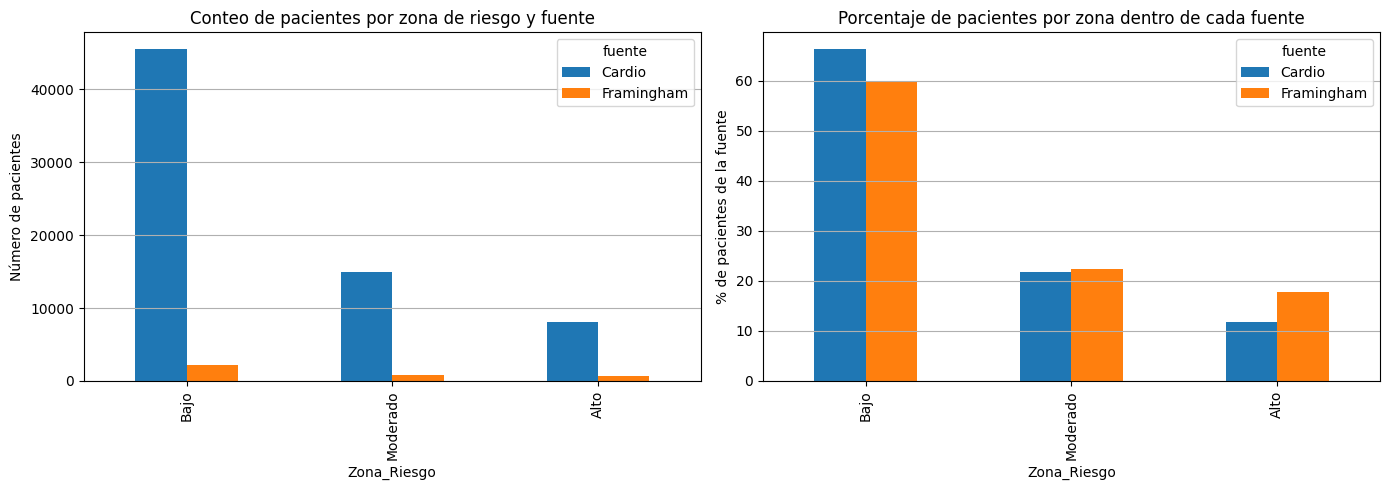


% de pacientes de cada fuente que caen en cada zona:
fuente       Cardio  Framingham
Zona_Riesgo                    
Alto          11.84       17.88
Bajo          66.38       59.68
Moderado      21.78       22.44


In [22]:
# Distribución por fuente dentro de cada zona (validación cruzada)
distribucion = pd.crosstab(XU['Zona_Riesgo'], XU['fuente'])
distribucion_pct = pd.crosstab(XU['Zona_Riesgo'], XU['fuente'], normalize='columns') * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
distribucion.reindex(['Bajo','Moderado','Alto']).plot(kind='bar', ax=axes[0], color=['#1f77b4', '#ff7f0e'])
axes[0].set_title('Conteo de pacientes por zona de riesgo y fuente')
axes[0].set_ylabel('Número de pacientes'); axes[0].grid(axis='y')

distribucion_pct.reindex(['Bajo','Moderado','Alto']).plot(kind='bar', ax=axes[1], color=['#1f77b4', '#ff7f0e'])
axes[1].set_title('Porcentaje de pacientes por zona dentro de cada fuente')
axes[1].set_ylabel('% de pacientes de la fuente'); axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

print("\n% de pacientes de cada fuente que caen en cada zona:")
print(distribucion_pct.round(2))

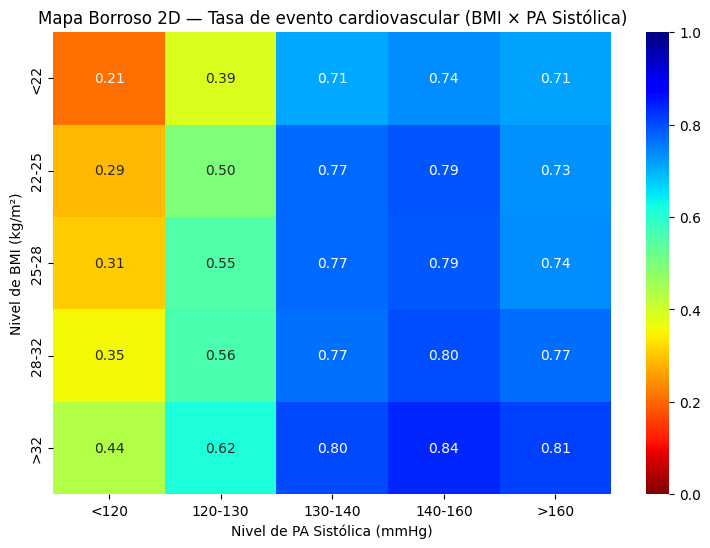

In [23]:
# Heatmap de tasa de evento cardiovascular por nivel de PA Sistólica × BMI
# Se discretizan ambas variables en cinco niveles para visualizar el mapa borroso 2D
XU['nv_PAs'] = pd.cut(XU['PA_sist'], bins=[0,120,130,140,160,300],
                      labels=['<120','120-130','130-140','140-160','>160'])
XU['nv_BMI'] = pd.cut(XU['BMI'], bins=[0,22,25,28,32,100],
                      labels=['<22','22-25','25-28','28-32','>32'])

heat = XU.pivot_table(values='cardio', index='nv_BMI', columns='nv_PAs', aggfunc='mean', observed=True)

plt.figure(figsize=(9, 6))
sns.heatmap(heat, annot=True, fmt='.2f', cmap='jet_r', vmin=0, vmax=1)
plt.title('Mapa Borroso 2D — Tasa de evento cardiovascular (BMI × PA Sistólica)')
plt.xlabel('Nivel de PA Sistólica (mmHg)')
plt.ylabel('Nivel de BMI (kg/m²)')
plt.show()

**5. Modelo II — Integración Multidimensional K-Medoids**

Se aplica el algoritmo K-Medoids visto en el Reto 4 sobre las cuatro variables comunes (age, PA_sist, PA_diast, BMI) para integrar a los pacientes de ambas fuentes en cinco perfiles o segmentos. A diferencia del modelo borroso (que utiliza umbrales clínicos fijos), K-Medoids deja que sean los propios datos los que definan los segmentos, lo que permite validar y complementar los hallazgos del modelo borroso. Para que las semillas iniciales recorran de manera uniforme el rango de cada variable, se utilizan como centroides iniciales los percentiles 10, 30, 50, 70 y 90 de la base unificada.

In [24]:
# Definición del modelo de integración K-Medoids (Reto 4)
def integracion_kmedoids(XD, XC, max_iter=1):
  # XD: matriz de datos (n x p)
  # XC: matriz inicial de centroides (k x p) - semillas de integracion
  # Devuelve: centroides finales y asignaciones por individuo
  XC = np.array(XC, dtype=float).copy()
  nc = np.zeros((len(XD), 1))

  for _ in range(max_iter):
    for k in range(len(XD)):
      Xind = XD[k, ]
      # Distancia relativa al cuadrado contra cada centroide
      denominador = np.where(XC == 0, 0.0001, XC)
      m1 = np.sum(((XC - Xind) / denominador) ** 2, axis=1)
      nc[k] = np.argmin(m1)
      cluster = int(np.argmin(m1))
      # Se actualiza el centroide con el promedio móvil
      XC[cluster, ] = (XC[cluster, ] + Xind) / 2

  return XC, nc

In [25]:
# Construcción de las semillas iniciales por percentiles y ejecución del modelo
variables = ['age', 'PA_sist', 'PA_diast', 'BMI']
XD = np.array(XU[variables], dtype=float)

percentiles = [10, 30, 50, 70, 90]
XC0 = np.array([[np.percentile(XD[:, i], p) for i in range(len(variables))] for p in percentiles])

print("Centroides iniciales (semillas):")
print(pd.DataFrame(XC0, columns=variables, index=[f'P{p}' for p in percentiles]).round(2))

np.random.seed(42)
XC, nc = integracion_kmedoids(XD, XC0)

print("\nCentroides finales luego de la integración:")
dfxc = pd.DataFrame(XC, columns=variables)
dfxc.index = [f'Perfil {j}' for j in range(5)]
display(dfxc.round(2))

Centroides iniciales (semillas):
      age  PA_sist  PA_diast    BMI
P10  42.0    110.0      70.0  22.04
P30  50.0    120.0      80.0  24.22
P50  54.0    120.0      80.0  26.28
P70  58.0    130.0      82.0  29.07
P90  62.0    150.0      90.0  34.22

Centroides finales luego de la integración:


,age,PA_sist,PA_diast,BMI
Perfil 0,56.05,146.28,89.02,27.01
Perfil 1,56.91,116.37,72.73,20.70
Perfil 2,52.99,153.95,95.38,34.76
Perfil 3,51.21,118.34,81.08,28.51
Perfil 4,43.26,109.11,74.61,25.76


In [26]:
# Caracterización de cada perfil: número de pacientes, fuente, tasa de evento
ND, TE, FRAM, CARD = [], [], [], []

for j in range(5):
    filas = np.where(nc[:, 0] == j)[0]
    nd = len(filas)
    if nd == 0:
        ND.append(0); TE.append(0); FRAM.append(0); CARD.append(0); continue

    tasa = XU.iloc[filas]['cardio'].mean()
    n_fram = int((XU.iloc[filas]['fuente'] == 'Framingham').sum())
    n_card = int((XU.iloc[filas]['fuente'] == 'Cardio').sum())

    print(f"--- Perfil {j} ---")
    print(f"Número de pacientes:        {nd}")
    print(f"Framingham / Cardio:        {n_fram} / {n_card}")
    print(f"Tasa de evento cardiovasc.: {tasa*100:.2f}%\n")

    ND.append(nd); TE.append(round(tasa*100, 2)); FRAM.append(n_fram); CARD.append(n_card)

dfxc['N_Pacientes']      = ND
dfxc['% Evento Cardio']  = TE
dfxc['N_Framingham']     = FRAM
dfxc['N_Cardio']         = CARD
display(dfxc.round(2))

--- Perfil 0 ---
Número de pacientes:        15016
Framingham / Cardio:        822 / 14194
Tasa de evento cardiovasc.: 48.69%

--- Perfil 1 ---
Número de pacientes:        13464
Framingham / Cardio:        670 / 12794
Tasa de evento cardiovasc.: 46.24%

--- Perfil 2 ---
Número de pacientes:        14850
Framingham / Cardio:        736 / 14114
Tasa de evento cardiovasc.: 46.67%

--- Perfil 3 ---
Número de pacientes:        14925
Framingham / Cardio:        738 / 14187
Tasa de evento cardiovasc.: 48.62%

--- Perfil 4 ---
Número de pacientes:        13990
Framingham / Cardio:        692 / 13298
Tasa de evento cardiovasc.: 48.34%



,age,PA_sist,PA_diast,BMI,N_Pacientes,% Evento Cardio,N_Framingham,N_Cardio
Perfil 0,56.05,146.28,89.02,27.01,15016,48.69,822,14194
Perfil 1,56.91,116.37,72.73,20.70,13464,46.24,670,12794
Perfil 2,52.99,153.95,95.38,34.76,14850,46.67,736,14114
Perfil 3,51.21,118.34,81.08,28.51,14925,48.62,738,14187
Perfil 4,43.26,109.11,74.61,25.76,13990,48.34,692,13298


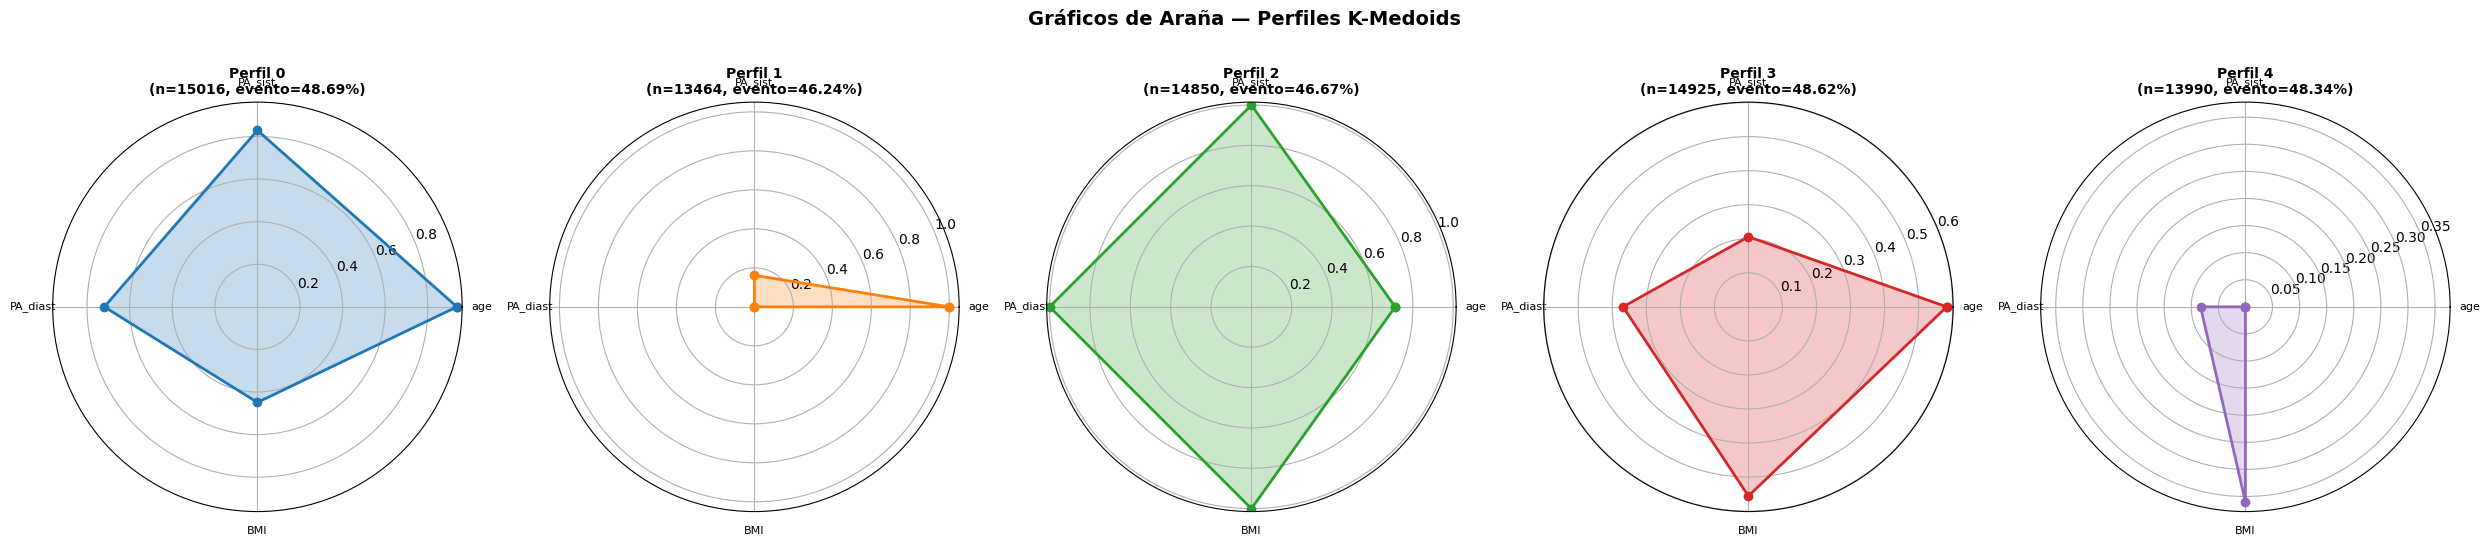

In [27]:
# Gráficos de araña — perfil de cada uno de los cinco segmentos
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
XC_norm = scaler.fit_transform(XC)
dfxc_norm = pd.DataFrame(XC_norm, columns=variables)

fig, axes = plt.subplots(1, 5, figsize=(25, 5), subplot_kw=dict(polar=True))
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for j in range(5):
    ax = axes[j]
    valores = dfxc_norm.iloc[j].values.tolist()
    valores += valores[:1]
    angulos = np.linspace(0, 2 * np.pi, len(variables), endpoint=False).tolist()
    angulos += angulos[:1]

    ax.plot(angulos, valores, 'o-', linewidth=2, color=colores[j])
    ax.fill(angulos, valores, alpha=0.25, color=colores[j])
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(variables, fontsize=8)
    ax.set_title(f'Perfil {j}\n(n={ND[j]}, evento={TE[j]}%)',
                 fontsize=10, fontweight='bold')

plt.suptitle('Gráficos de Araña — Perfiles K-Medoids', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

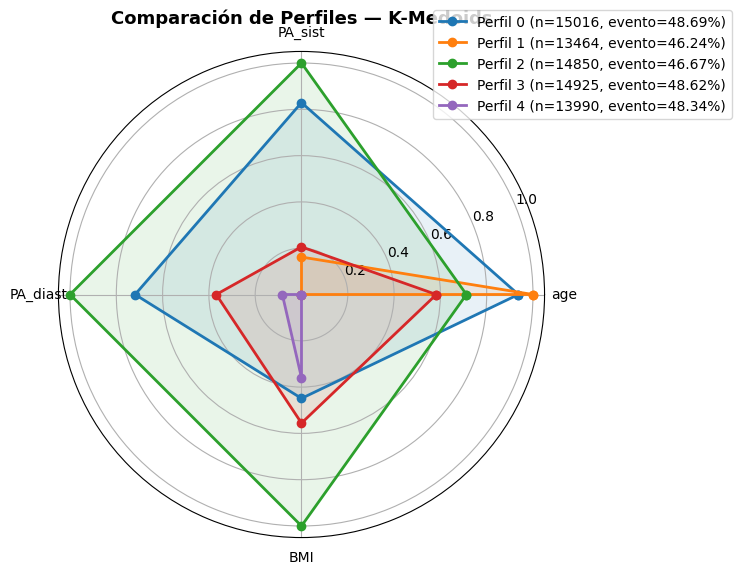

In [28]:
# Gráfico de araña consolidado de los cinco perfiles
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

angulos = np.linspace(0, 2 * np.pi, len(variables), endpoint=False).tolist()
angulos += angulos[:1]

for j in range(5):
    valores = dfxc_norm.iloc[j].values.tolist()
    valores += valores[:1]
    ax.plot(angulos, valores, 'o-', linewidth=2, color=colores[j],
            label=f'Perfil {j} (n={ND[j]}, evento={TE[j]}%)')
    ax.fill(angulos, valores, alpha=0.1, color=colores[j])

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(variables, fontsize=10)
ax.set_title('Comparación de Perfiles — K-Medoids', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1))
plt.tight_layout()
plt.show()

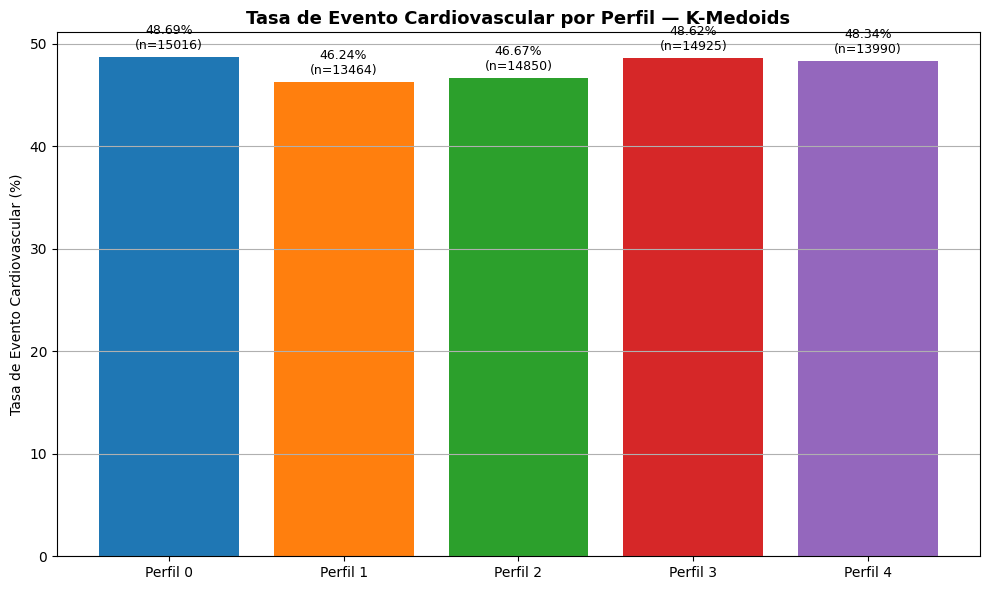

In [29]:
# Tasa de evento cardiovascular por perfil
x = np.arange(5)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(x, TE, color=colores)
ax.set_xticks(x); ax.set_xticklabels([f'Perfil {j}' for j in range(5)])
ax.set_ylabel('Tasa de Evento Cardiovascular (%)')
ax.set_title('Tasa de Evento Cardiovascular por Perfil — K-Medoids',
             fontsize=13, fontweight='bold')

for bar, t, n in zip(bars, TE, ND):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{t}%\n(n={n})', ha='center', va='bottom', fontsize=9)

ax.grid(axis='y')
plt.tight_layout()
plt.show()

**6. Comparación de los dos modelos y validación cruzada**

Se cruzan las clasificaciones del Modelo I (Borroso) y del Modelo II (K-Medoids) para evaluar la coherencia de la integración. Una alta concentración a lo largo de la diagonal del cruce indica que ambos modelos identifican los mismos perfiles de riesgo, lo que valida el proceso de integración multidimensional.

In [30]:
# Asignación de zona K-Medoids ordenada por tasa de evento (Bajo a Alto)
XU['Perfil_KMed'] = nc[:, 0].astype(int)

# Se ordenan los perfiles K-Medoids de menor a mayor tasa de evento
orden_perfiles = pd.Series(TE).sort_values().index.tolist()
zona_kmed_map = {orden_perfiles[0]: 'Bajo',
                 orden_perfiles[1]: 'Bajo-Medio',
                 orden_perfiles[2]: 'Medio',
                 orden_perfiles[3]: 'Medio-Alto',
                 orden_perfiles[4]: 'Alto'}
XU['Zona_KMed'] = XU['Perfil_KMed'].map(zona_kmed_map)

print("Tasa de evento por perfil K-Medoids (ordenado):")
for p in orden_perfiles:
    print(f"  Perfil {p} → {zona_kmed_map[p]:<11} | evento: {TE[p]:.2f}% | n = {ND[p]}")


Tasa de evento por perfil K-Medoids (ordenado):
  Perfil 1 → Bajo        | evento: 46.24% | n = 13464
  Perfil 2 → Bajo-Medio  | evento: 46.67% | n = 14850
  Perfil 4 → Medio       | evento: 48.34% | n = 13990
  Perfil 3 → Medio-Alto  | evento: 48.62% | n = 14925
  Perfil 0 → Alto        | evento: 48.69% | n = 15016


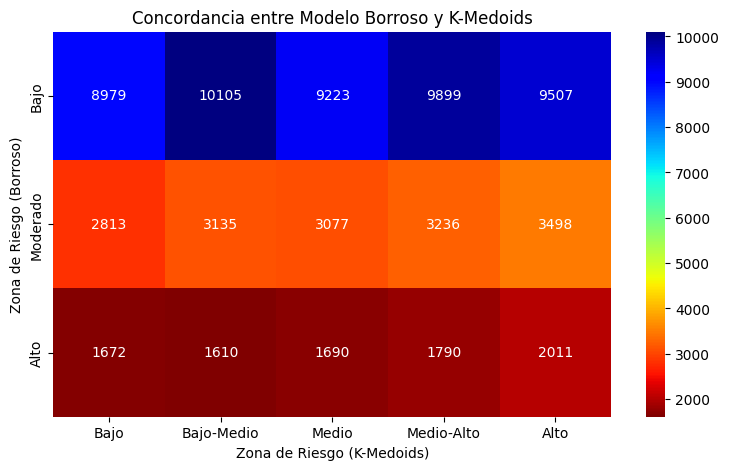


Índice de concordancia entre los dos modelos: 44.75%


In [31]:
# Cruce entre el modelo borroso y el modelo K-Medoids
cruce = pd.crosstab(XU['Zona_Riesgo'], XU['Zona_KMed'])
cruce = cruce.reindex(index=['Bajo', 'Moderado', 'Alto'],
                      columns=['Bajo', 'Bajo-Medio', 'Medio', 'Medio-Alto', 'Alto'])

plt.figure(figsize=(9, 5))
sns.heatmap(cruce, annot=True, fmt='.0f', cmap='jet_r')
plt.title('Concordancia entre Modelo Borroso y K-Medoids')
plt.xlabel('Zona de Riesgo (K-Medoids)')
plt.ylabel('Zona de Riesgo (Borroso)')
plt.show()

# Índice de concordancia: % de pacientes en la diagonal extendida
total = cruce.values.sum()
diag = (cruce.loc['Bajo', ['Bajo', 'Bajo-Medio']].sum() +
        cruce.loc['Moderado', ['Bajo-Medio', 'Medio', 'Medio-Alto']].sum() +
        cruce.loc['Alto', ['Medio-Alto', 'Alto']].sum())
print(f"\nÍndice de concordancia entre los dos modelos: {diag/total*100:.2f}%")


Resumen integrado:


,N,Tasa_Evento,Modelo
Bajo,47713,0.346,Borroso
Moderado,15759,0.699,Borroso
Alto,8773,0.793,Borroso
Bajo,13464,0.462,K-Medoids
Bajo-Medio,14850,0.467,K-Medoids
Medio,13990,0.483,K-Medoids
Medio-Alto,14925,0.486,K-Medoids
Alto,15016,0.487,K-Medoids


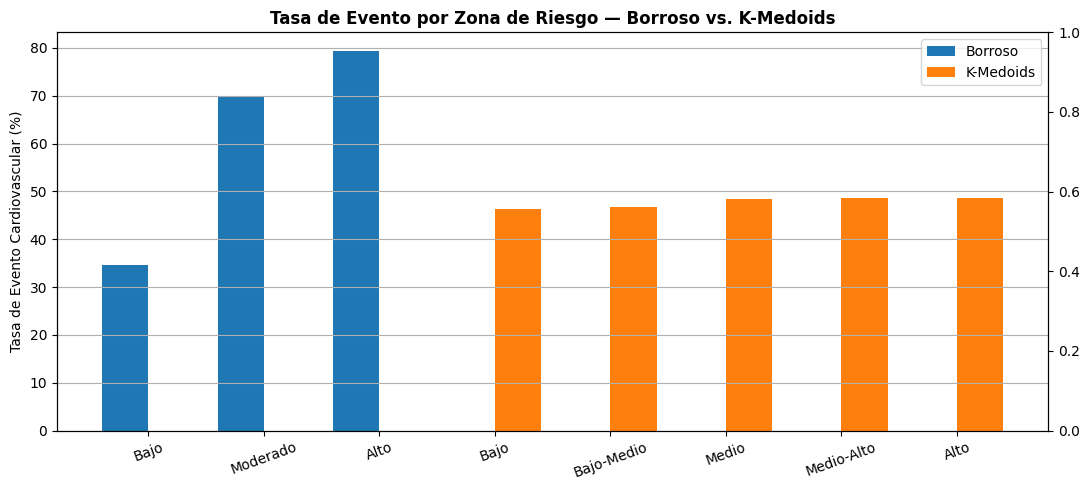

In [32]:
# Resumen integrado: tasa de evento por zona en cada modelo
res_borroso = XU.groupby('Zona_Riesgo', observed=True)['cardio'].agg(['size', 'mean']).reindex(['Bajo','Moderado','Alto'])
res_borroso.columns = ['N', 'Tasa_Evento']
res_borroso['Modelo'] = 'Borroso'

res_kmed = XU.groupby('Zona_KMed', observed=True)['cardio'].agg(['size', 'mean']).reindex(['Bajo','Bajo-Medio','Medio','Medio-Alto','Alto'])
res_kmed.columns = ['N', 'Tasa_Evento']
res_kmed['Modelo'] = 'K-Medoids'

print("Resumen integrado:")
display(pd.concat([res_borroso, res_kmed]).round(3))

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(11, 5))
x1 = np.arange(len(res_borroso))
x2 = np.arange(len(res_kmed))

ax2 = ax.twinx()
ax.bar(x1 - 0.2, res_borroso['Tasa_Evento']*100, width=0.4, color='#1f77b4', label='Borroso')
ax.bar(x2 + 0.2 + max(x1) + 1, res_kmed['Tasa_Evento']*100, width=0.4, color='#ff7f0e', label='K-Medoids')

xticks = list(x1) + list(x2 + max(x1) + 1)
xlabels = list(res_borroso.index) + list(res_kmed.index)
ax.set_xticks(xticks); ax.set_xticklabels(xlabels, rotation=20)
ax.set_ylabel('Tasa de Evento Cardiovascular (%)')
ax.set_title('Tasa de Evento por Zona de Riesgo — Borroso vs. K-Medoids',
             fontsize=12, fontweight='bold')
ax.grid(axis='y')
ax.legend()
plt.tight_layout()
plt.show()

# **Análisis de Resultados**